In [1]:
!pip -q install pandas numpy matplotlib seaborn openpyxl

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("figures", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

sns.set(style="whitegrid", context="talk")
np.random.seed(42)

In [3]:
data = [
    ["ds006072", "working_memory", 42, True, True],
    ["ds006072", "attention", 42, True, True],
    ["Dataset_B", "cognitive_flexibility", 30, True, False],
    ["Dataset_C", "episodic_memory", 28, True, True],
    ["Dataset_D", "emotion_regulation", 35, False, True],
    ["Dataset_E", "processing_speed", 26, True, False],
]

df = pd.DataFrame(
    data,
    columns=[
        "dataset",
        "domain",
        "n_subjects",
        "imaging_available",
        "behavior_available"
    ]
)

df

,dataset,domain,n_subjects,imaging_available,behavior_available
0,ds006072,working_memory,42,True,True
1,ds006072,attention,42,True,True
2,Dataset_B,cognitive_flexibility,30,True,False
3,Dataset_C,episodic_memory,28,True,True
4,Dataset_D,emotion_regulation,35,False,True
5,Dataset_E,processing_speed,26,True,False


In [4]:
summary = (
    df.groupby("domain")["n_subjects"]
    .sum()
    .reset_index()
    .sort_values("n_subjects", ascending=False)
)

summary

,domain,n_subjects
0,attention,42
5,working_memory,42
2,emotion_regulation,35
1,cognitive_flexibility,30
3,episodic_memory,28
4,processing_speed,26


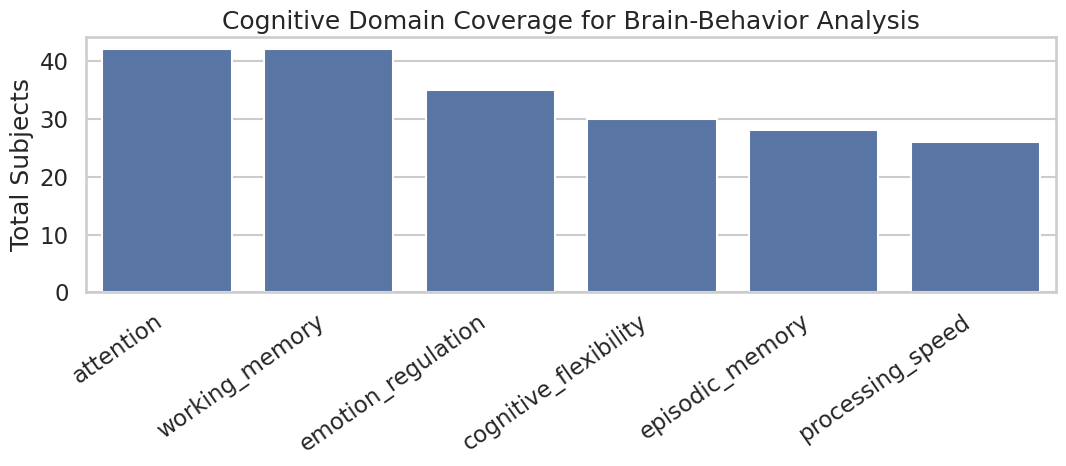

In [5]:
plt.figure(figsize=(11,5))

sns.barplot(
    data=summary,
    x="domain",
    y="n_subjects"
)

plt.xticks(rotation=35, ha="right")
plt.xlabel("")
plt.ylabel("Total Subjects")
plt.title("Cognitive Domain Coverage for Brain-Behavior Analysis")
plt.tight_layout()
plt.savefig("figures/01_domain_landscape.png", dpi=300)
plt.show()

In [6]:
ready = df[
    (df["imaging_available"] == True) &
    (df["behavior_available"] == True)
]

ready.to_csv("outputs/01_ready_datasets.csv", index=False)
df.to_csv("outputs/01_full_landscape.csv", index=False)

ready

,dataset,domain,n_subjects,imaging_available,behavior_available
0,ds006072,working_memory,42,True,True
1,ds006072,attention,42,True,True
3,Dataset_C,episodic_memory,28,True,True
